# Use MVTec AD Dataset via API

# Installing Anomalib

The easiest way to install anomalib is to use pip. You can install it from the command line using the following command:


In [ ]:
%pip install anomalib

In [1]:
# flake8: noqa
import numpy as np
from PIL import Image
from torchvision.transforms.v2.functional import to_pil_image

from anomalib.data import MVTecAD, MVTecADDataset

## Setting up the Dataset Directory

This cell is to ensure we change the directory to have access to the datasets.


In [2]:
from pathlib import Path

# NOTE: Provide the path to the dataset root directory.
#   If the datasets is not downloaded, it will be downloaded
#   to this directory.
print("current working directory:", Path.cwd())
dataset_root = Path.cwd().parent.parent.parent / "datasets" / "MVTecAD"
print("dataset root directory:", dataset_root)

current working directory: /home/admin_rech/repos/anomalib/examples/02_data/datamodules
dataset root directory: /home/admin_rech/repos/anomalib/datasets/MVTecAD


### DataModule

Anomalib data modules are based on PyTorch Lightning (PL)'s `LightningDataModule` class. This class handles all the boilerplate code related to subset splitting, and creating the dataset and dataloader instances. A datamodule instance can be directly passed to a PL Trainer which is responsible for carrying out Anomalib's training/testing/inference pipelines.

In the current example, we will show how an Anomalib data module can be created for the MVTec Dataset, and how we can obtain training and testing dataloaders from it.

To create a datamodule, we simply pass the path to the root folder of the dataset on the file system, together with some basic parameters related to pre-processing and image loading:


In [3]:
mvtec_datamodule = MVTecAD(
    root=dataset_root,
    category="bottle",
    train_batch_size=32,
    eval_batch_size=32,
    num_workers=0,
)

For the illustrative purposes of the current example, we need to manually call the `prepare_data` and `setup` methods. Normally it is not necessary to call these methods explicitly, as the PL Trainer would call these automatically under the hood.

`prepare_data` checks if the dataset files can be found at the specified file system location. If not, it will download the dataset and place it in the folder.

`setup` applies the subset splitting and prepares the PyTorch dataset objects for each of the train/val/test subsets.


In [4]:
mvtec_datamodule.prepare_data()
mvtec_datamodule.setup()

After the datamodule has been set up, we can use it to obtain the dataloaders of the different subsets.


In [5]:
# Train images
i, data = next(enumerate(mvtec_datamodule.train_dataloader()))
print(data.image.shape)

torch.Size([32, 3, 900, 900])


In [6]:
# Test images
i, data = next(enumerate(mvtec_datamodule.test_dataloader()))
print(data.image.shape, data.gt_mask.shape)

torch.Size([32, 3, 900, 900]) torch.Size([32, 900, 900])


As can be seen above, creating the dataloaders are pretty straghtforward, which could be directly used for training/testing/inference. We could visualize samples from the dataloaders as well.


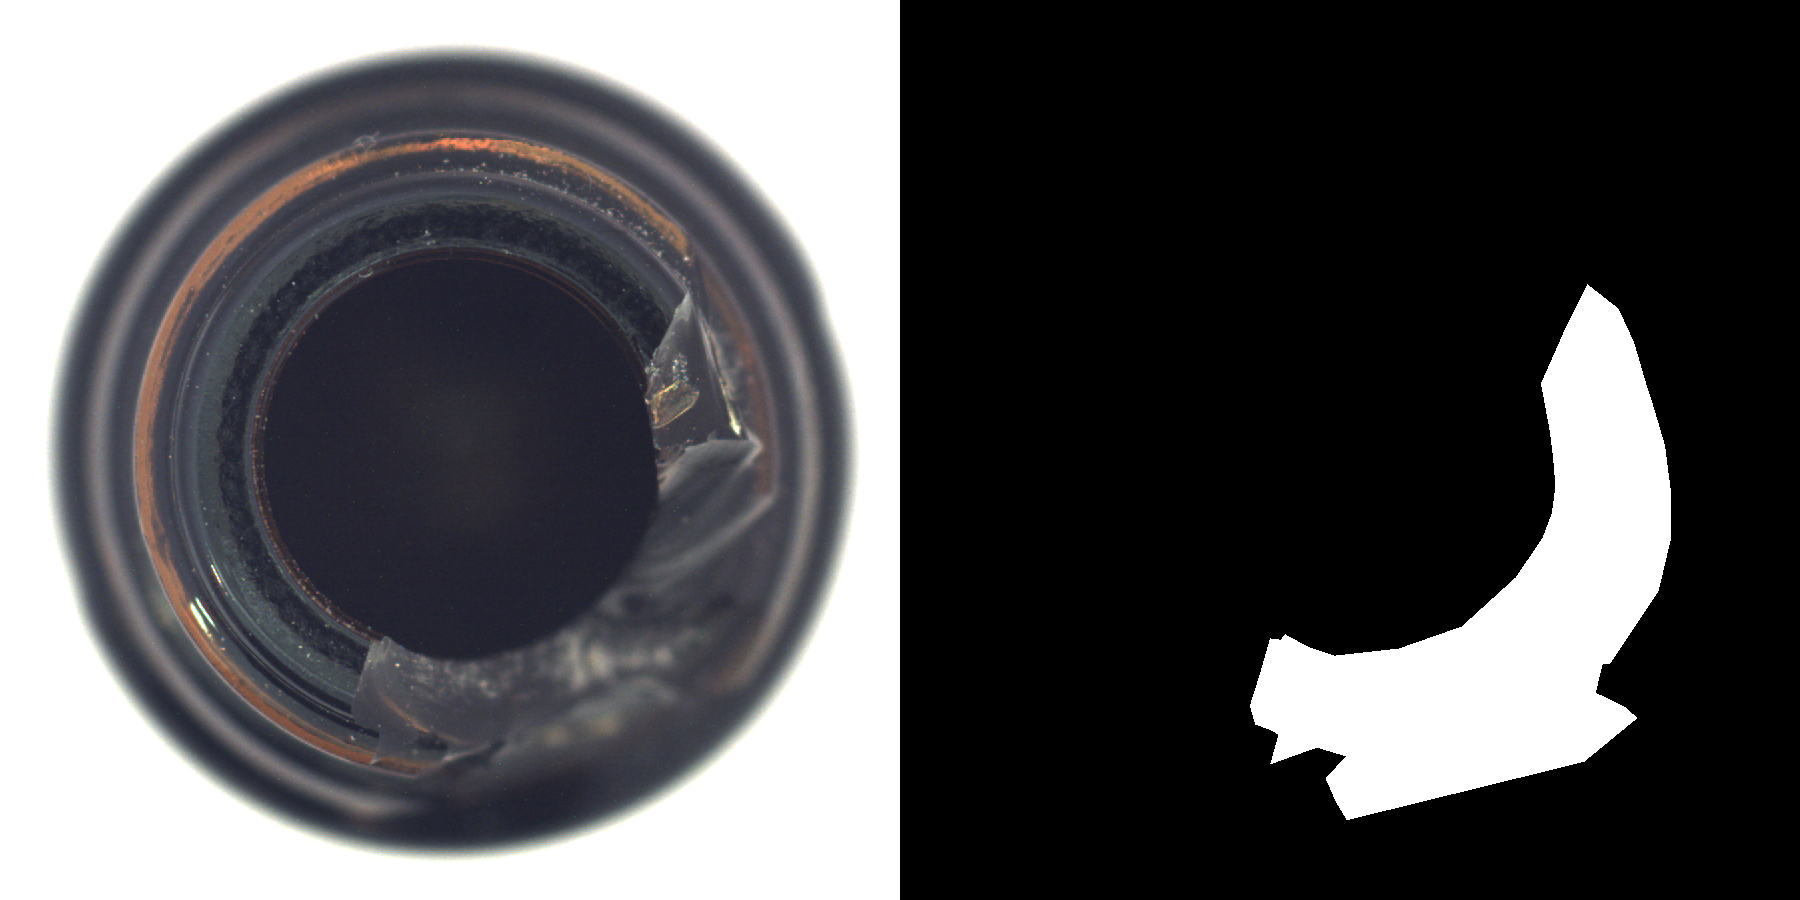

In [7]:
img = to_pil_image(data.image[0].clone())
msk = to_pil_image(data.gt_mask[0].int() * 255).convert("RGB")

Image.fromarray(np.hstack((np.array(img), np.array(msk))))

### Torch Dataset

In some cases it might be desirable to create a standalone PyTorch dataset without a PL data module. For example, this could be useful for training a PyTorch model outside Anomalib, so without the use of a PL Trainer instance. In such cases, the PyTorch Dataset instance can be instantiated directly.


In [8]:
MVTecADDataset??

Init signature:
MVTecADDataset(
    root: pathlib.Path | str = './datasets/MVTecAD',
    category: str = 'bottle',
    augmentations: torchvision.transforms.v2._transform.Transform | None = None,
    split: str | anomalib.data.utils.split.Split | None = None,
) -> None
Source:        
class MVTecADDataset(AnomalibDataset):
    """MVTec AD dataset class.

    Dataset class for loading and processing MVTec AD dataset images. Supports
    both classification and segmentation tasks.

    Args:
        root (Path | str): Path to root directory containing the dataset.
            Defaults to ``"./datasets/MVTecAD"``.
        category (str): Category name, must be one of ``CATEGORIES``.
            Defaults to ``"bottle"``.
        augmentations (Transform, optional): Augmentations that should be applied to the input images.
            Defaults to ``None``.
        split (str | Split | None, optional): Dataset split - usually
            ``Split.TRAIN`` or ``Split.TEST``. Defaults to ``None`

Now let's create the dataset, we'll start with the training subset.

In [9]:
# MVTec dataset
mvtec_dataset_train = MVTecADDataset(
    root=dataset_root,
    category="bottle",
    split="train",
)
print(len(mvtec_dataset_train))
sample = mvtec_dataset_train[0]
print(sample.image.shape, sample.image_path, sample.gt_label)

209
torch.Size([3, 900, 900]) /home/admin_rech/repos/anomalib/datasets/MVTecAD/bottle/train/good/000.png tensor(False)


As can be seen above, when we choose `train` split, the dataset contains 209 samples. These are the normal training samples from the MVTec bottle category, which have a corresponding ground truth label of `False`, indicating that the image does not contain an anomaly. 

Now let's have a look at the test set:


In [10]:
# MVTec Classification Test Set
mvtec_dataset_test = MVTecADDataset(
    root=dataset_root,
    category="bottle",
    split="test",
)
print(len(mvtec_dataset_test))
sample = mvtec_dataset_test[0]
print(sample.image.shape, sample.image_path, sample.gt_label)

83
torch.Size([3, 900, 900]) /home/admin_rech/repos/anomalib/datasets/MVTecAD/bottle/test/broken_large/000.png tensor(True)


Let's visualize the image and the mask...


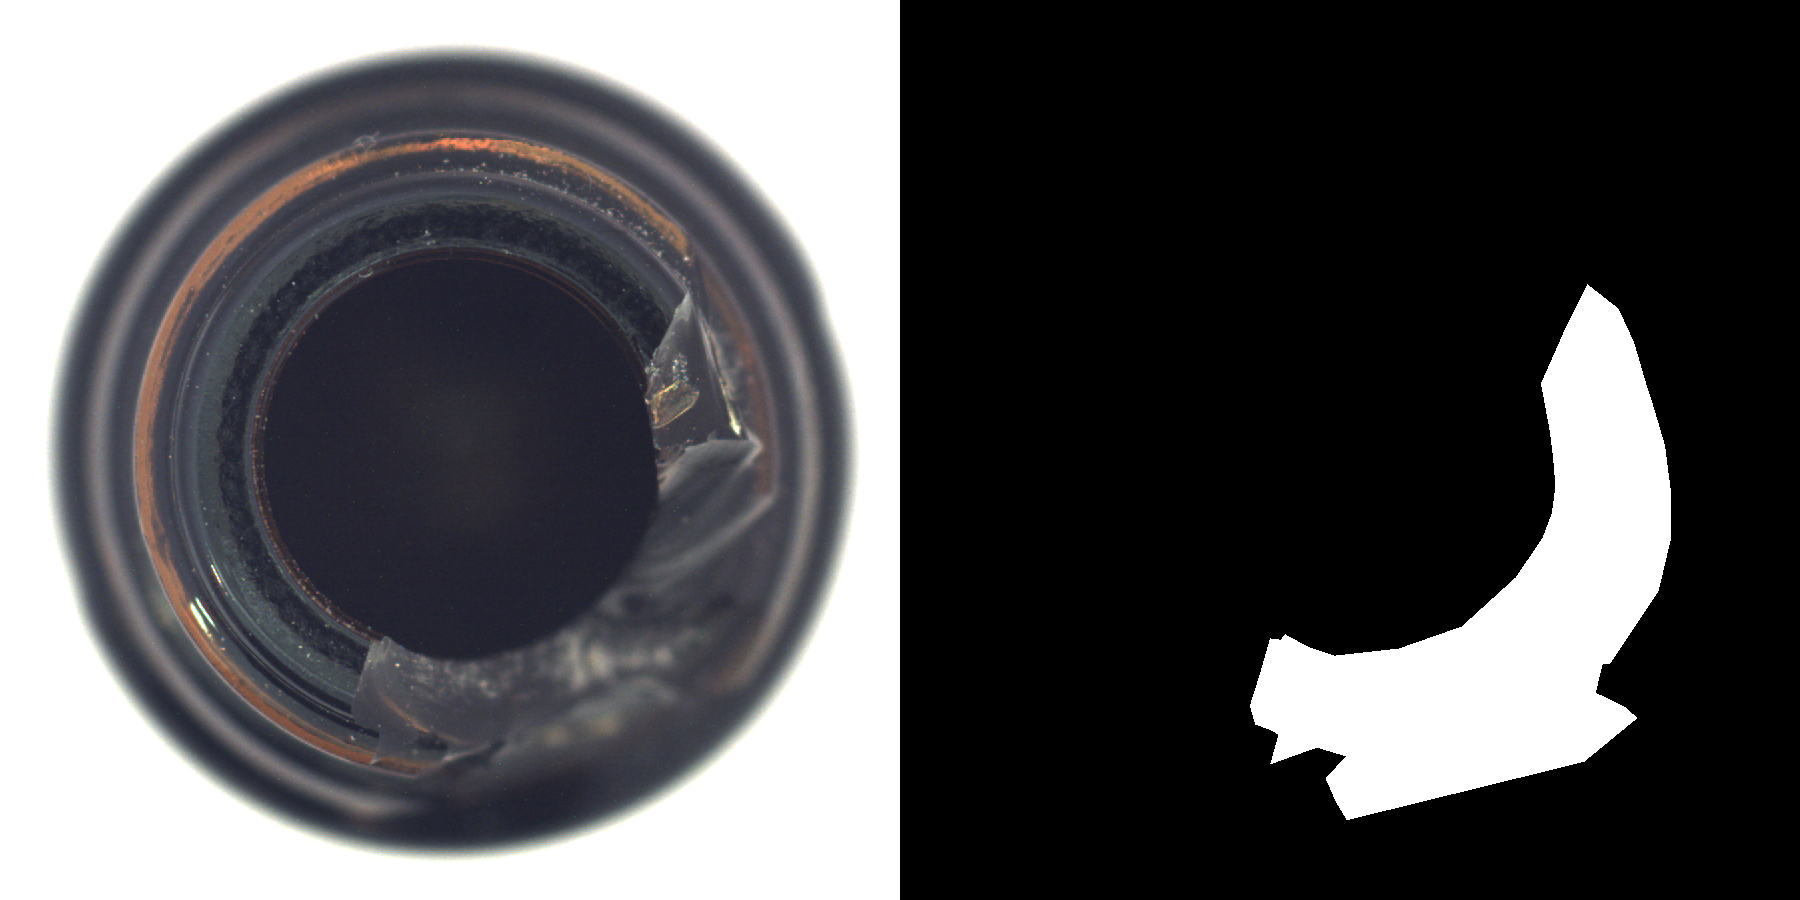

In [11]:
img = to_pil_image(sample.image.clone())
msk = to_pil_image(sample.gt_mask.int() * 255).convert("RGB")

Image.fromarray(np.hstack((np.array(img), np.array(msk))))